In [223]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [224]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression

In [225]:
df=pd.read_csv('data/concrete_data.csv')

In [226]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [228]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [229]:
X=df.drop(columns=['Strength'])

In [230]:
Y=df.iloc[:,-1]

In [231]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=84)

In [232]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2_score(y_pred,y_test)

0.4325491071905754

In [233]:
model=LinearRegression()
np.mean(cross_val_score(model,X,Y,scoring='r2'))

np.float64(0.4609940491662864)

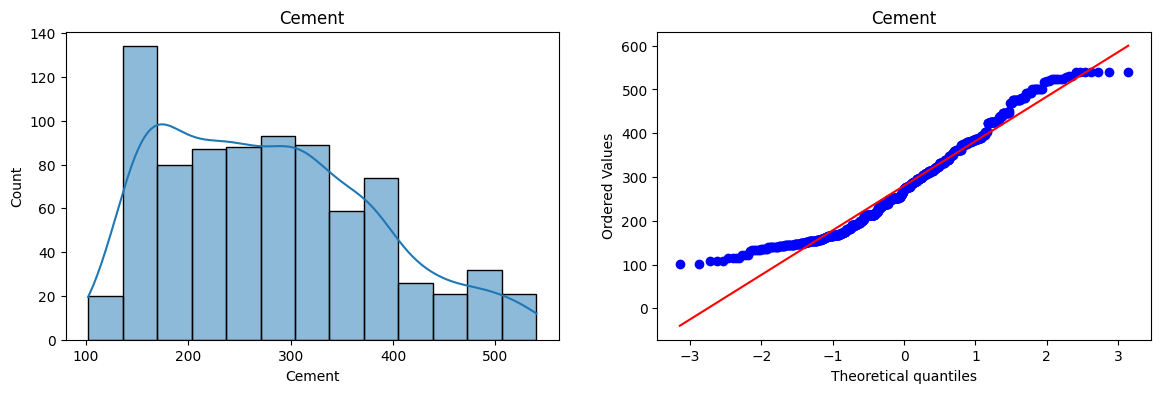

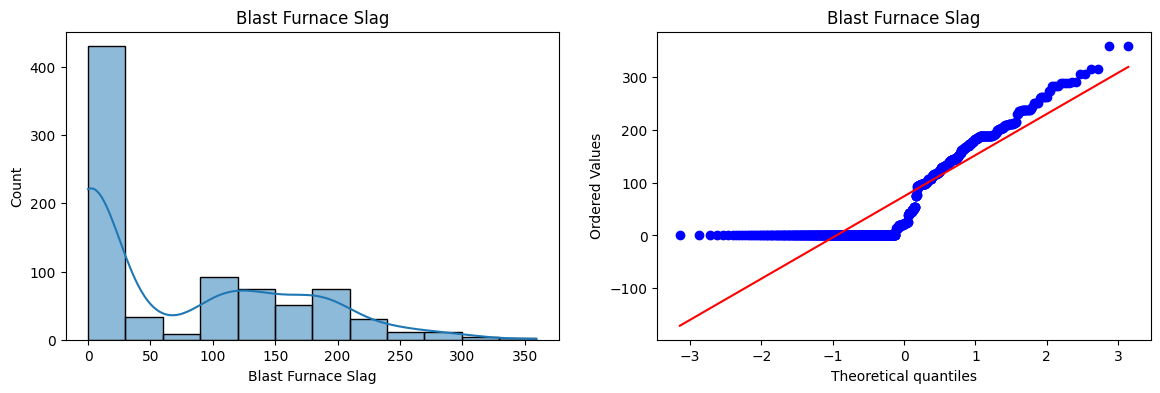

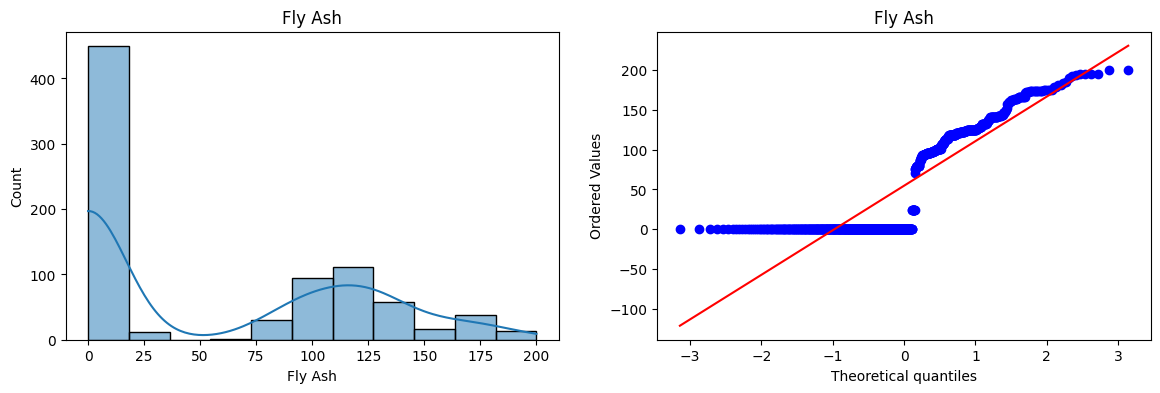

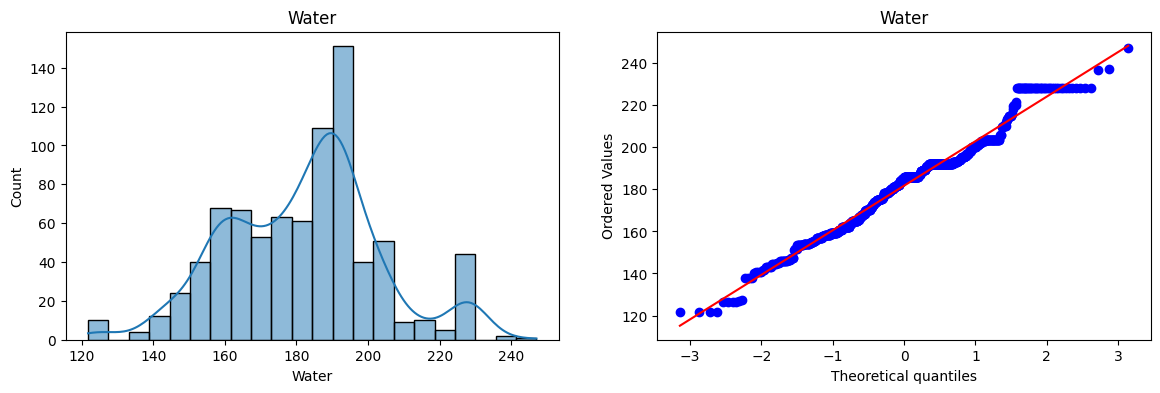

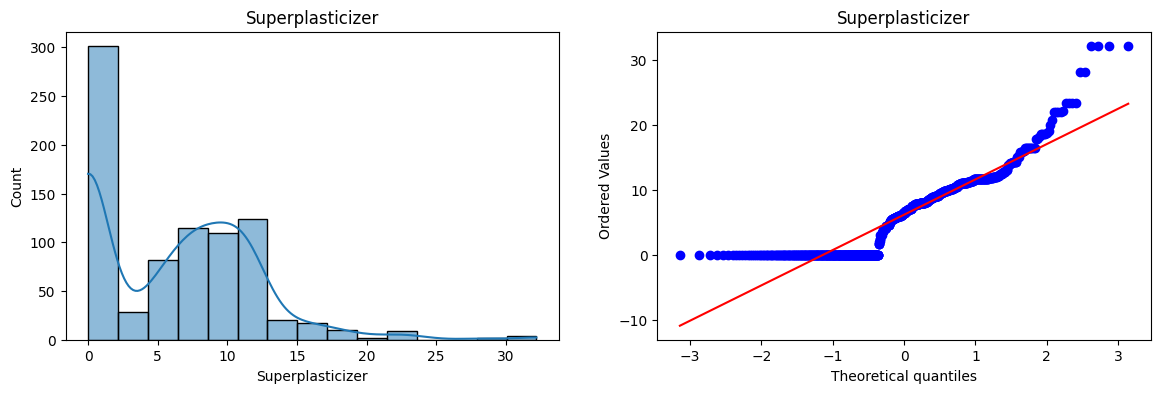

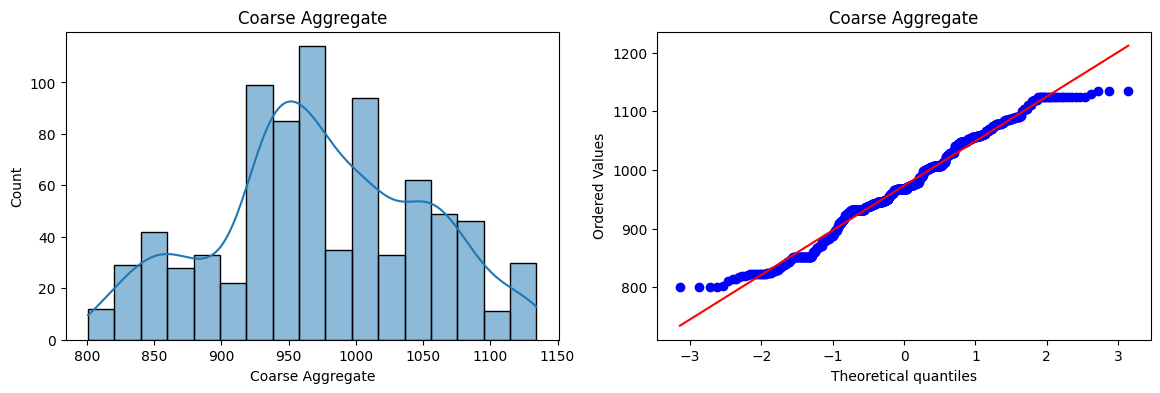

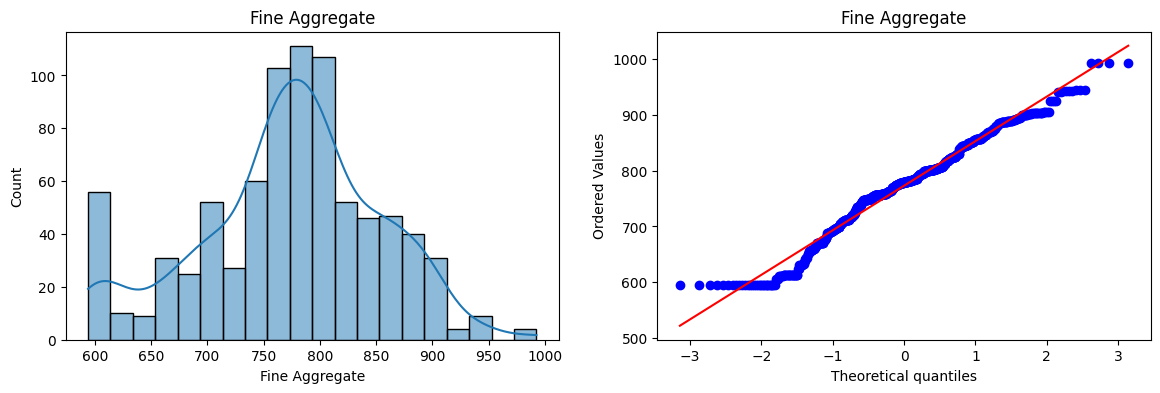

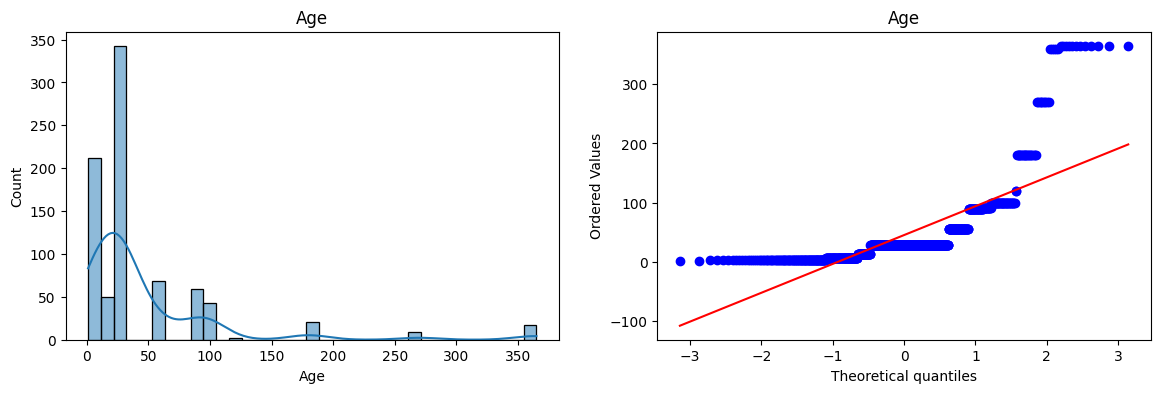

In [234]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=1)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()

In [235]:
pt=PowerTransformer(method='box-cox')
x_train_trnf=pt.fit_transform(x_train+0.00000000001)
x_test_trnf=pt.fit_transform(x_test+0.00000000000001)
pd.DataFrame({'cols':X.columns,'Box_cox_lamda':pt.lambdas_})

,cols,Box_cox_lamda
0,Cement,0.210423
1,Blast Furnace Slag,0.007638
2,Fly Ash,-0.022330
3,Water,0.752390
4,Superplasticizer,0.036083
5,Coarse Aggregate,0.810697
6,Fine Aggregate,1.347184
7,Age,0.058183


In [236]:
lr=LinearRegression()
lr.fit(x_train_trnf,y_train)
y_pred2=lr.predict(x_test_trnf)
r2_score(y_test,y_pred2)

0.8001054060957798

In [237]:
pt=PowerTransformer(method="box-cox")
lr=LinearRegression()
X_trnf=pt.fit_transform(X+0.0000000000000001)
np.mean(cross_val_score(lr,X_trnf,Y,scoring='r2'))

np.float64(0.6639435521618443)

In [238]:
x_train_trnf=pd.DataFrame(x_train_trnf,columns=x_train.columns)

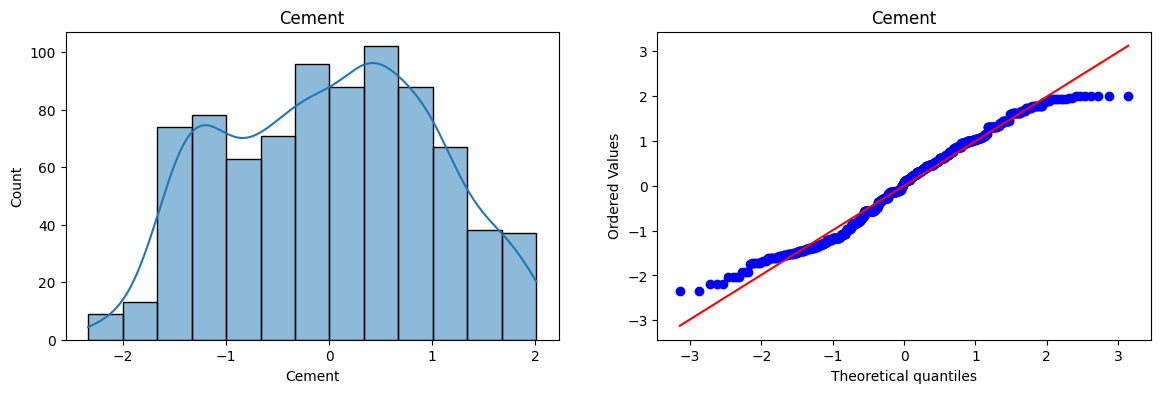

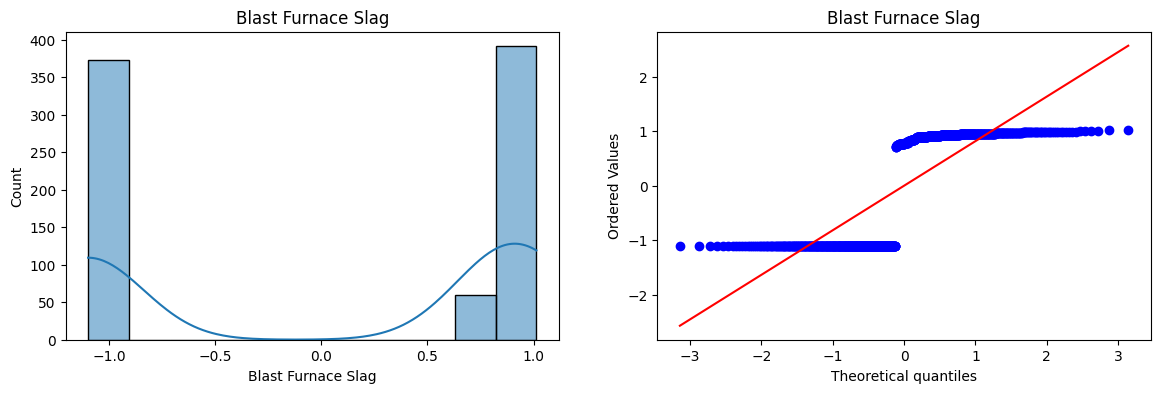

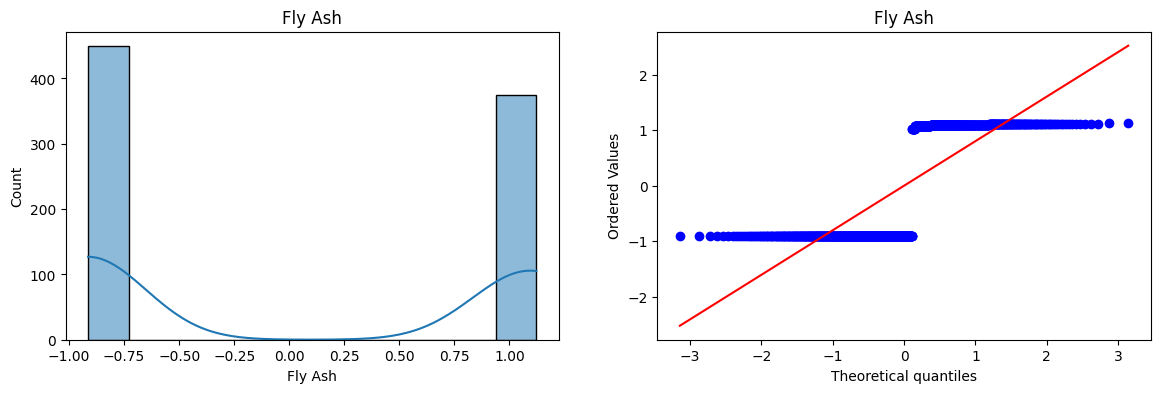

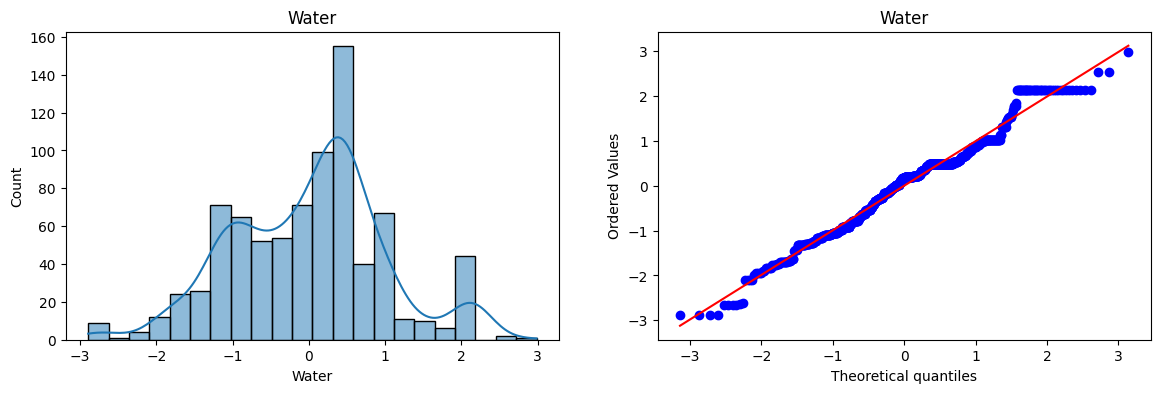

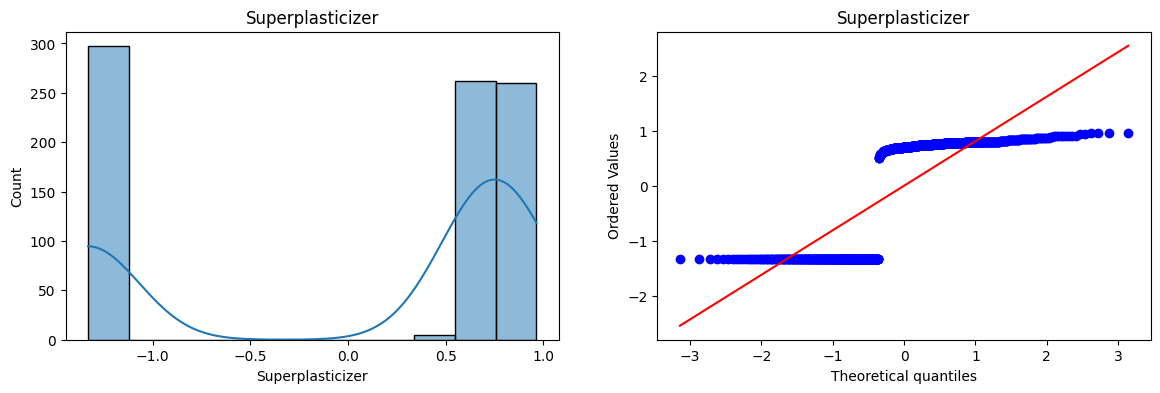

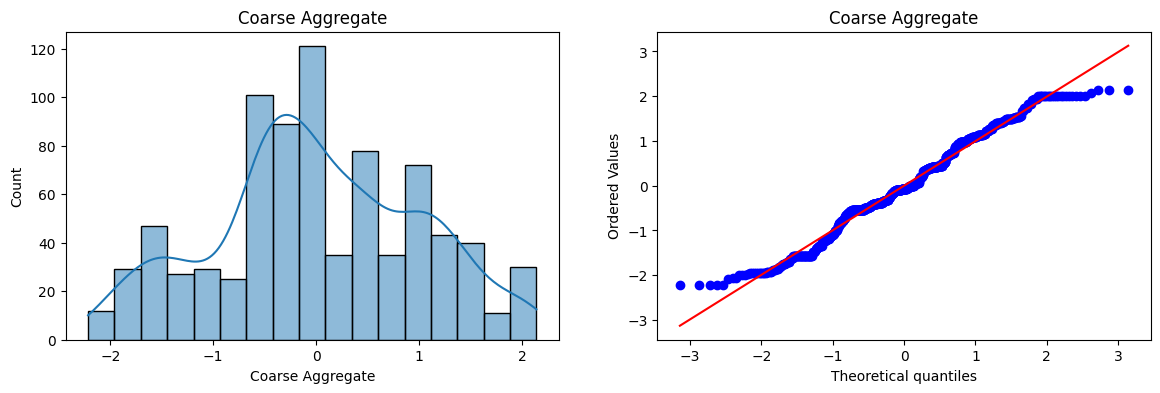

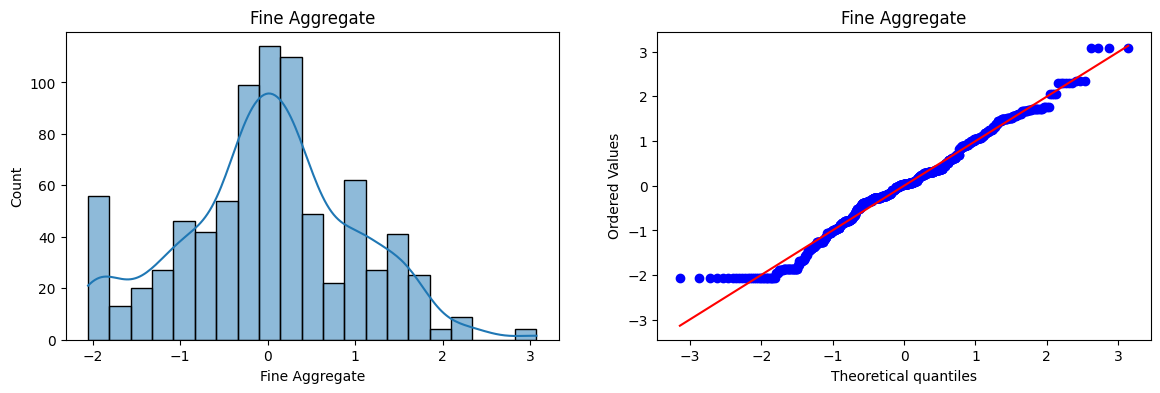

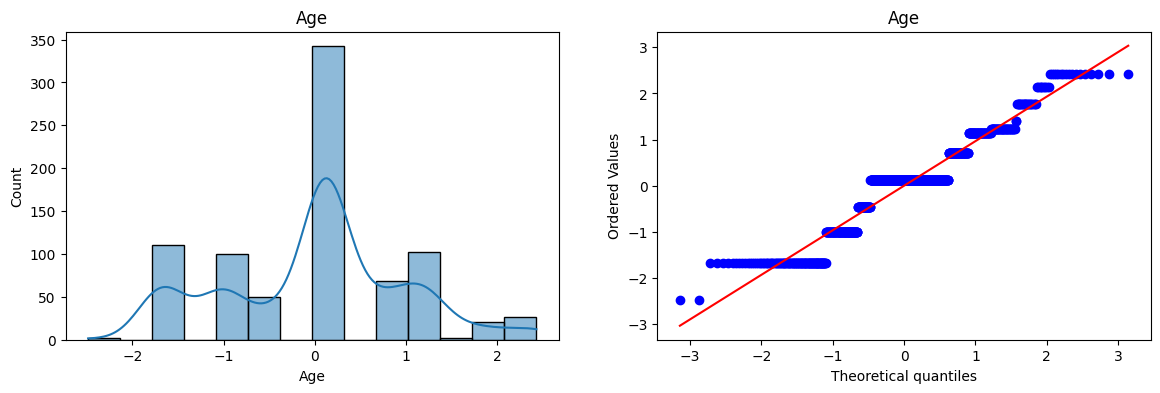

In [239]:
for col in x_train_trnf.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train_trnf[col],kde=1)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train_trnf[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()

In [244]:
pt=PowerTransformer()
x_train_trnf2=pt.fit_transform(x_train)
x_test_trnf2=pt.fit_transform(x_test)
x_trnf2=pt.fit_transform(X)

In [245]:
lr.fit(x_train_trnf2,y_train)
ypred3=lr.predict(x_test_trnf2)
r2_score(y_test,ypred3)

0.8077367578776187

In [246]:

np.mean(cross_val_score(lr,x_trnf2,Y,scoring="r2"))

np.float64(0.6834625126992433)

In [248]:
x_train_trnf2=pd.DataFrame(x_train_trnf2,columns=x_train.columns)

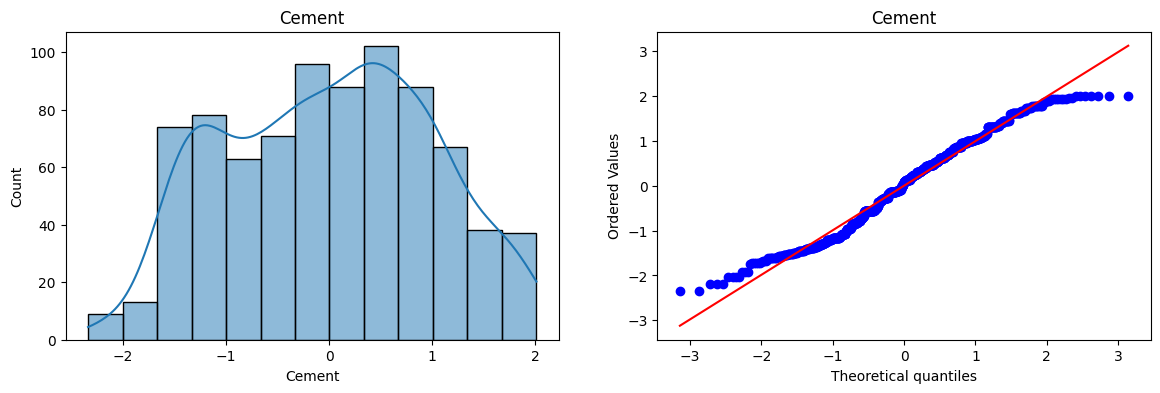

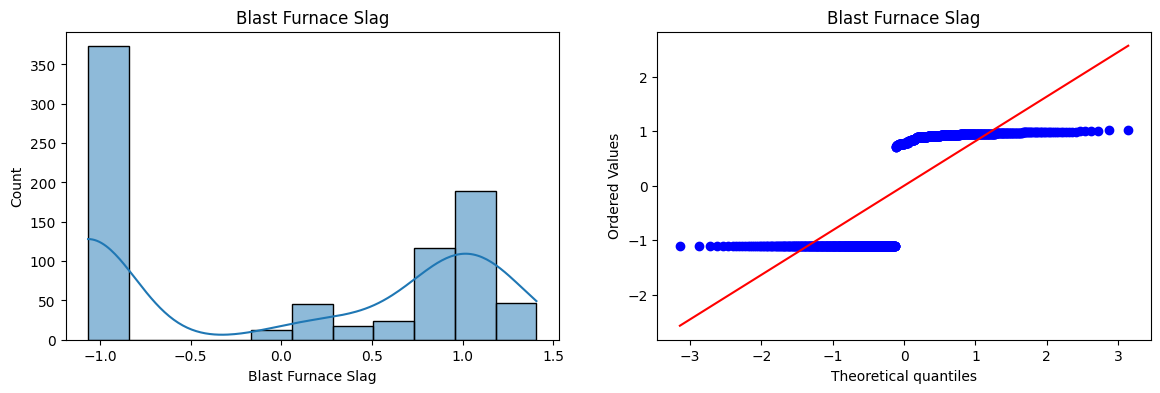

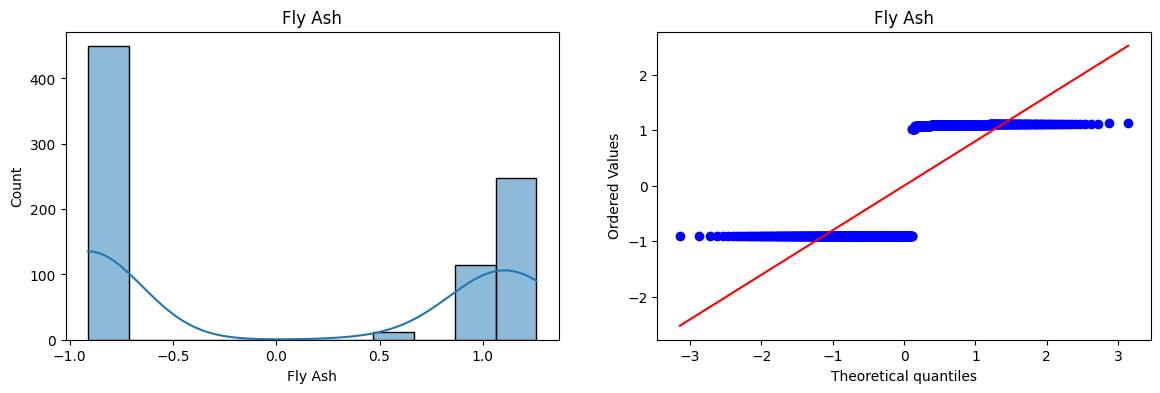

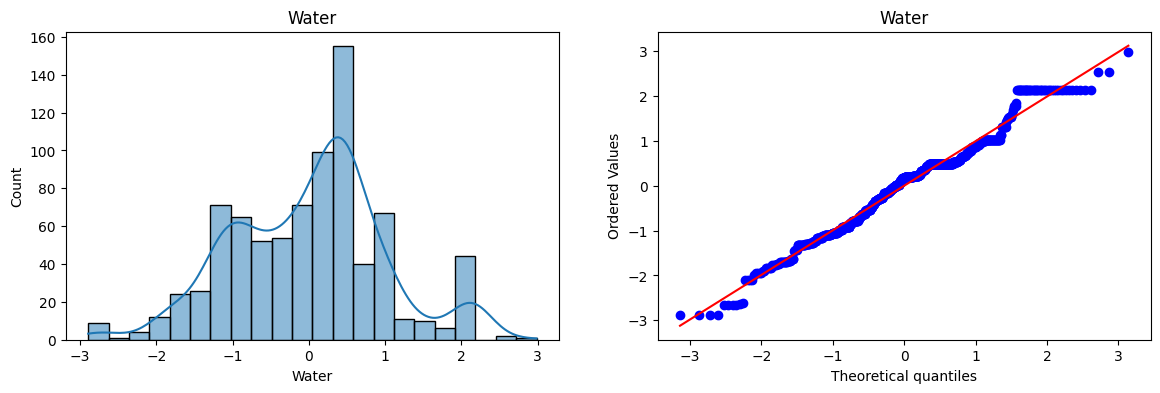

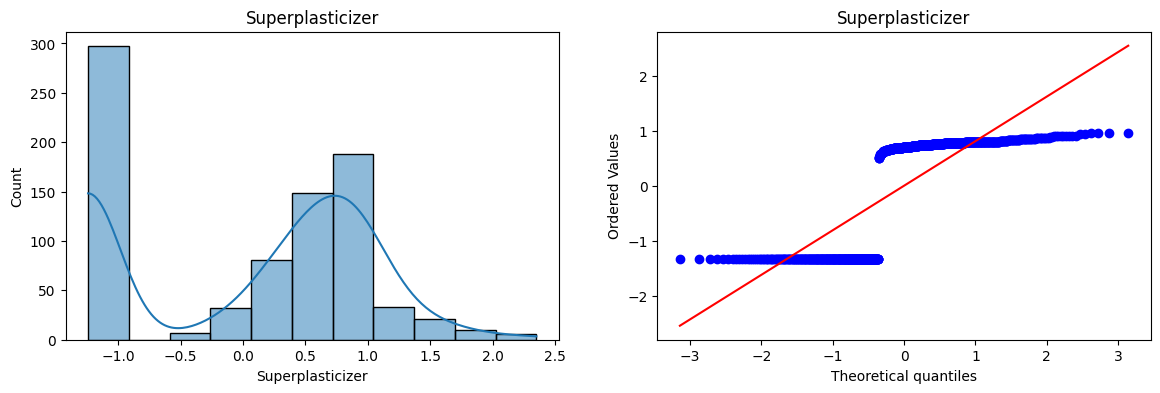

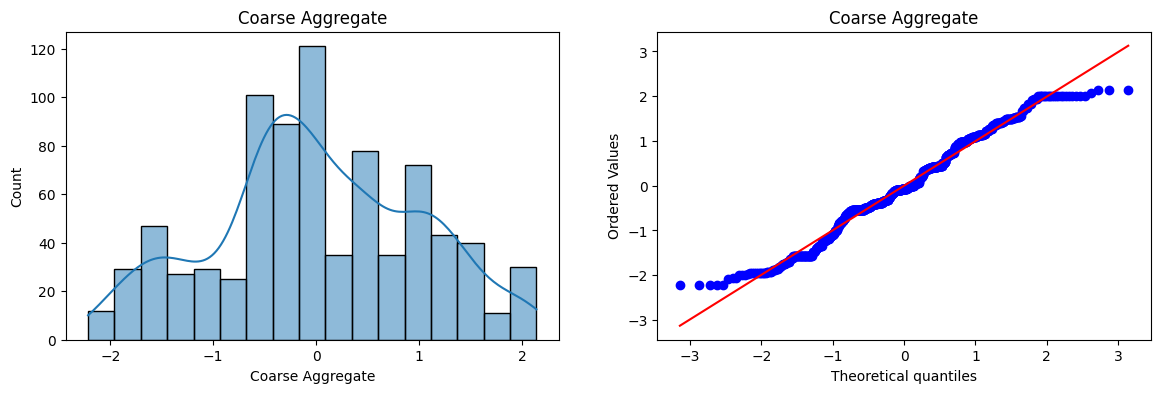

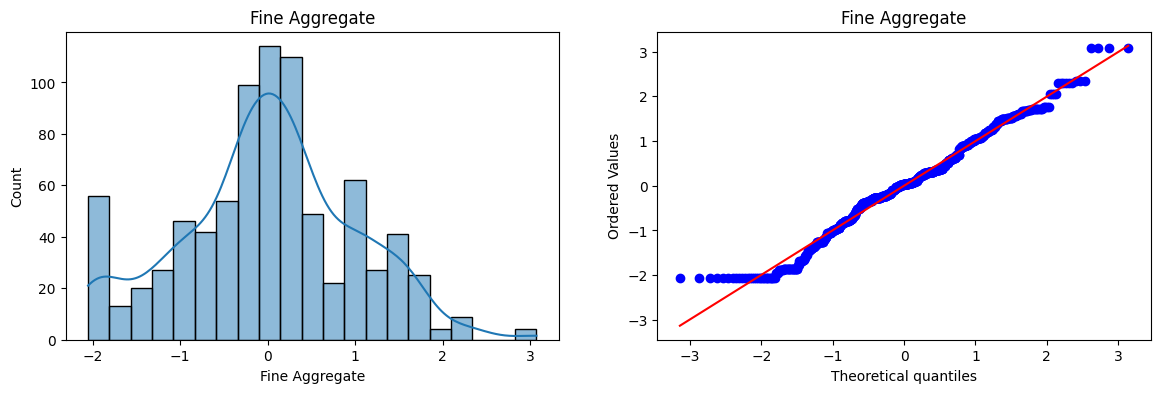

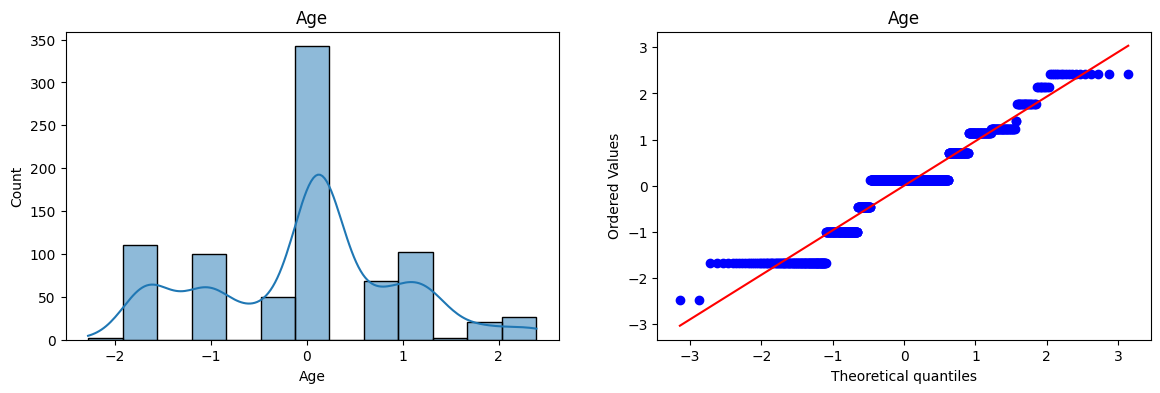

In [249]:
for col in x_train_trnf2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train_trnf2[col],kde=1)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train_trnf[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()